# Bioreactor Modeling: Governing Equations and Design Basis

In this tutorial, we will learn how to design and model bioreactors for anaerobic, aerobic, and CO2/H2 gas-fed fermentations. We will first introduce the governing phenomenological equations (i.e., mass and energy balances, heat and mass transfer), then move into the following case studies, ordered by increasing complexity:

* **Anaerobic fermentation:** conventional corn ethanol production.
* **Aerobic fermentation:** microbial oil production from sugar.
* **CO2/H2 gas-fed fermentation:** acetic acid production from blast furnace steelmaking flue gas.

The goals of this case study are to:

* Understand the governing equations and design basis of bioreactors in BioSTEAM.
* Apply BioSTEAM unit operations to model different fermentation processes.
* Understand the difference between anaerobic, aerobic, and gas-fed fermentations in terms of modeling complexity and economic impact.  

## Governing phenomenological equations

There are 4 governing phenomenological equations that need to be satisfied in a bioreactor:

$\text{Mass\ balance}: ∑_{i\mathrm{\ \in\ products}} F_i - ∑_{i\mathrm{\ \in\ feeds}} F_i = ∑_i R_i$

$\text{Energy\ balance}: \mathrm{Cooling\ Duty} = ∑_{i\mathrm{\ \in\ products}} H_i - ∑_{i\mathrm{\ \in\ feeds}} H_i$

$\text{Mass\ transfer}: \mathrm{Gas\ Uptake\ Rate = Gas\ Transfer\ Rate}$

$\text{Heat\ transfer}: \mathrm{Cooling\ Duty = Heat\ Transfer\ Rate}$    

* **$F$** - Molar flow rate of an arbitrary chemical
* **$R$** - Generation rate
* **$H$** - Enthalpy flow rate

For a specific fermentation performance (e.g., titer and yield), we can solve for our mass and energy balances. This leaves us with the heat and mass transfer requirements, which must be satisfied by the detailed design of the bioreactor and its components (e.g., vessel, heat exchanger, compressor, agitator). Alternatively, given a specified design (e.g., vessel aspect ratio, agitation, gas flow rate), we could let the gas mass transfer rate dictate the fermentation performance. 

In the following examples we will assume an experimentally verified fermentation performance and solve for the design of the bioreactor. As an exercise, we will first solve the problem manually with the help of BioSTEAM's thermodynamic engine. Then, we will verify our results using BioSTEAM Unit Operations.

## Corn ethanol anaerobic bioreactor

In the conventional dry-grind process for corn ethanol production, the corn is first liquified and saccharified to create a slurry. This glucose is then fermented to ethanol and carbon dioxide using yeast:

$\mathrm{Glucose \rightarrow 2\ Ethanol + 2\ CO_2}$

We will assume the following fermentation performance:

* Feed flow rate: 150,000 kg$\cdot$h$^{-1}$
* Feed glucose concentration: 20% wt
* Ethanol yield: 95% theoretical
* Temperture: 32 $\degree$C

In [1]:
feed_flow = 150000
x_Glucose = 0.20
yield_EtOH = 0.95
T_operation = 32 + 273.15

### Mass balance

We can solve for the total product flow rates by reacting the feed assuming the given yield. Mathematically, this translates to:

$ F_{i,\ \mathrm{out}} = F_{i,\ \mathrm{in}} + C_i \cdot X_{\mathrm{Glucose}} \cdot F_{\mathrm{Glucose,\ in}} $

* $X$ - Extent of reaction.
* $C$ - Stoichiometric reaction coefficient.
* $i$ - Index for an arbitrary chemical.

We can model the stoichiometric reaction using [Reaction](../API/thermosteam/Reaction.txt) objects to "react" a stream. 

To compute the flow rate of chemicals as they partition into the gas and liquid phases (i.e., the vent and effluent streams), we need to meet the vapor-liquid equilibrium criteria, which translates to the fugacity of each chemical in each phase must be the same. 

$ f^\alpha_i = f^\beta_i$

- $f^\alpha$ - Fugacity in phase $\alpha$ [Pa].
- $f^\beta$ - Fugacity in phase $\beta$  [Pa].

Phase equilibrium can be challenging to solve given how fugacity is a highly nonlinear and tightly coupled function of composition, temperature, and pressure. In BioSTEAM, we can quickly perform vapor-liquid equilibrium to partition the flows into the vent and effluent streams:

In [2]:
import biosteam as bst; bst.nbtutorial()
from biosteam.units.design_tools import aeration

# Define chemicals
bst.settings.set_thermo(
    ['Water', 'Ethanol', 'Glucose', 'CO2', 'Yeast'], 
    db='BioSTEAM'
)

# Create the feed
feed = bst.Stream(
    Water=1 - x_Glucose, 
    Glucose=x_Glucose,
    total_flow=feed_flow,
    units='kg/hr',
    T=T_operation,
    P=101325,
)

# Create product streams
broth = bst.Stream()
vent = bst.Stream(phase='g')
product = bst.MultiStream.from_streams([vent, broth])

# Define the reaction
production = bst.Reaction(
    'Glucose -> 2 Ethanol + 2 CO2',
    X=yield_EtOH,
)
growth = bst.Reaction(
    'Glucose -> Yeast',
    X=yield_EtOH, 
    correct_mass_balance=True,
)
fermentation = bst.ReactionSystem(production, growth)

# Convert the feed to product
broth.copy_like(feed)
fermentation(broth)

# Perform vapor-liquid equilibrium (uses Henry's constants). 
# Using product.vle(T=T_operation, P=101325) also works, but less accurate for fermentation broths.  
aeration.vent_broth(vent, broth) 

feed.show('cwt')
print()
fermentation.show()
print()
product.show('cwt')

Stream: feed
phase: 'l', T: 305.15 K, P: 101325 Pa
flow (%): Water    80
          Glucose  20
          -------  1.5e+05 kg/hr

ReactionSystem:
[0]  Reaction (by mol):
     stoichiometry                 reactant    X[%]
     Glucose -> 2 Ethanol + 2 CO2  Glucose    95.00
[1]  Reaction (by mol):
     stoichiometry          reactant    X[%]
     Glucose -> 7.97 Yeast  Glucose    95.00

MultiStream: 
phases: ('g', 'l'), T: 305.15 K, P: 101325 Pa
flow (%): (g) Water    1.38
              Ethanol  1.59
              CO2      97
              -------  1.42e+04 kg/hr
          (l) Water    88.2
              Ethanol  10.6
              Glucose  0.0552
              CO2      0.125
              Yeast    1.05
              -------  1.36e+05 kg/hr


### Energy balance

Now that we have solved the mass balance, we can estimate our cooling duty. The enthalpy flow rate of a stream depends on the temperature, pressure, and material flow rates. In BioSTEAM, we can estimate the enthalpy of a stream by using the [Stream.H](https://biosteam.readthedocs.io/en/latest/API/thermosteam/Stream.html#thermosteam.Stream.H) and [Stream.Hf](https://biosteam.readthedocs.io/en/latest/API/thermosteam/Stream.html#thermosteam.Stream.Hf) properties. Note that `H` does include heats of formation at its reference state while `Hf` is just the heats of formation.

In [3]:
cooling_duty = (product.Hf + product.H) - (feed.Hf + feed.H) # Enthalpy change (including heats of formation)
print('cooling duty:', f'{cooling_duty:.3g}', 'kJ/hr')

cooling duty: -1.37e+07 kJ/hr


### Bioreactor sizing

To size the bioreactor, we will need to make the following heurstic design specifications:

* $R$ - length to diameter: 3
* $V_{\mathrm{max}}$ - maximum reactor volume: 1000 m3
* $f$ - working volume: 90%
* $\tau_{\mathrm{reaction}}$ - reaction time: 60 h
* $\tau_{\mathrm{cleaning}}$ - clean up time: 3 h
* $\tau_{\mathrm{loading}}$ - loading time: 1 h
* $R$ - height to diameter ratio: 3

This allows us to solve for the reactor volume, number of reactors, and reactor dimensions:

$ V_{\mathrm{total}} = \nu(\tau_{\mathrm{reaction}} + \tau_{\mathrm{cleaning}} + \tau_{\mathrm{loading}}) \cdot f^{-1} $

$ N_{\mathrm{reactors}} = \mathrm{ceil}(V_{\mathrm{total}} \cdot V_{\mathrm{max}^{-1}}) $

$ V_{\mathrm{reactor}} = V_{\mathrm{total}} N_{\mathrm{reactors}}^{-1} $

$ D = (4 \pi  V_{\mathrm{reactor}} R)^{1/3} $

$ H = D \cdot R $

* $\nu$ - Volumetric flow rate
* $N_{reactors}$ - Number of reactors
* $V_{total}$ - Total volume of all reactors
* $V_{reactor}$ - Volume of a reactor
* $D$ - Diameter
* $H$ - Height


In [4]:
from math import ceil, pi as π

# Heuristic specifications
R = 3
V_max = 1000
f = 0.90
tau_reaction = 60
tau_cleanup = 3
tau_loading = 1

# Solve for number of reactors and the volume of an individual reactor 
𝜈 = product['l'].F_vol
V_total = 𝜈 * (tau_reaction + tau_cleanup + tau_loading) / f
N_reactors = ceil(V_total / V_max)
V_reactor = V_total / N_reactors
print('Number of reactors:', N_reactors)
print('Reactor volume:', f"{V_reactor:.3g}", 'm3')

# Solve for the diameter and height
D = (4 * V_reactor / π / R)**(1/3)
H = D * R
print('Reactor height:', f"{H:.3g}", 'm')
print('Reactor diameter:', f"{D:.3g}", 'm')

Number of reactors: 10
Reactor volume: 998 m3
Reactor height: 22.5 m
Reactor diameter: 7.51 m


## Heat exchange

The most commonly used bioreactor heat exchanger configuration is the jacketed vessel. A full jacket provides a constant heat transfer area to the medium. In order to meet the cooling requirement, the flow rate of the cooling agent (e.g., chilled water) can be varied. The greater the flow rate, the greater the overall heat transfer coefficient, and the greater the driving force (i.e., the temperature difference across the jacket). Because the temperature of the utility changes across the jacket, we use the log-mean temperature difference as the driving force (LMTD).

$ Q = U A \Delta T_{\mathrm{LMTD}} $

$ Q = F_{\mathrm{utility}} (h_\mathrm{utility,\ in} - h_\mathrm{utility,\ out}) $ 

$ \Delta T_{\mathrm{LMTD}} = (\Delta T_{\mathrm{in}}-\Delta T_{\mathrm{out}}) \ln(\Delta T_{\mathrm{in}} / \Delta T_{\mathrm{out}})^{-1} $

$ \Delta T_{\mathrm{in}} = T_{\mathrm{utility,\ in}} - T_{\mathrm{operation}} $

$ \Delta T_{\mathrm{out}} = T_{\mathrm{utility,\ out}} - T_{\mathrm{operation}} $

* $U$ - Overall heat trasfer coefficient
* $Q$ - Cooling duty
* $T$ - Temperature
* $h$ - Specific molar enthalpy

Estimating the overall heat transfer coefficient can be challenging due to its dependence on detailed design of the bioreactor (e.g., agitation) and mixture properties (e.g., density, conductivity). As a preliminary estimate, we can assume that the temperature of the outlet utility is simply the maximum allowable temperature for smooth regeneration (chilled water cannot come back too hot to the cooler). Because the cost of chilled water usage is estimated based on the total heat transfered (not on the actual flow rate), this assumption does not impact our economic analysis. 

In [5]:
# Additional assumptions/specifications
T_utility_out = 27.22 + 273.15
T_utility_in = 7.22 + 273.15

# Solve for utility requirements
chilled_water_in = bst.Stream(Water=1, T=T_utility_in)
chilled_water_out = bst.Stream(Water=1, T=T_utility_out)
F_utility = cooling_duty / (chilled_water_in.h - chilled_water_out.h)

print('Chilled water flow rate:',  f'{F_utility:.3g}', 'kmol/hr')

Chilled water flow rate: 9.07e+03 kmol/hr


### Standard anaerobic bioreactor model

BioSTEAM streamlines the modeling, design, costing of bioreactors. Let's use BioSTEAM's [AnaerobicBioreactor](https://biosteam.readthedocs.io/en/latest/API/units/anaerobic_bioreactor.html) model to model the corn ethanol fermentation:

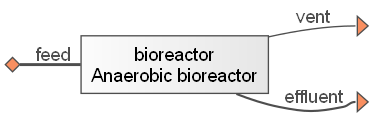

AnaerobicBioreactor: bioreactor
ins...
[0] feed  
    phase: 'l', T: 305.15 K, P: 101325 Pa
    flow (%): Water    80
              Glucose  20
              -------  1.5e+05 kg/hr
outs...
[0] vent  
    phase: 'g', T: 305.15 K, P: 101325 Pa
    flow (%): Water    1.38
              Ethanol  1.59
              CO2      97
              -------  1.42e+04 kg/hr
[1] effluent  
    phase: 'l', T: 305.15 K, P: 101325 Pa
    flow (%): Water    88.2
              Ethanol  10.6
              Glucose  0.0552
              CO2      0.125
              Yeast    1.05
              -------  1.36e+05 kg/hr


In [6]:
import biosteam as bst; bst.nbtutorial()

bioreactor = bst.AnaerobicBioreactor(
    ins=feed, 
    outs=('vent', 'effluent'),
    reactions=fermentation,
    T=T_operation,
    V_wf=f,
    V_max=V_max,
    tau=tau_reaction,
    tau_0=tau_cleanup,
    loading_time=tau_loading,
    length_to_diameter=R,
    heat_exchanger_configuration='jacketed',
)
bioreactor.simulate()
bioreactor.diagram(format='png')
bioreactor.show('cwt')

In [7]:
bioreactor.results(basis='SI')

Anaerobic bioreactor                                            Units           bioreactor
Electricity              Power                                     kW                 90.4
                         Cost                                  USD/hr                 7.07
Chilled water            Duty                                   kJ/hr            -1.37e+07
                         Flow                                 kmol/hr             9.17e+03
                         Cost                                  USD/hr                 68.4
Design                   Reactor volume                            m³                  913
                         Batch time                                hr                   64
                         Loading time                              hr                    1
                         Number of reactors                                             11
                         Residence time                            hr                   60
                         Vessel type                                              Vertical
                         Length                                     m                 21.9
                         Diameter                                   m                 7.29
                         Weight                                    kg             1.12e+05
                         Wall thickness                             m               0.0119
                         Jacketed diameter                          m                  7.4
                         Vessel material                               Stainless steel 316
Purchase cost            Vertical pressure vessel (jacket...      USD             4.63e+06
                         Platform and ladders (x11)               USD             9.69e+05
                         Agitator - Agitator (x11)                USD             1.77e+05
Total purchase cost                                               USD             5.78e+06
Installed equipment cost                                          USD             2.04e+07
Utility cost                                                   USD/hr                 75.5

Note how all BioSTEAM results match our calculations.

### NREL anaerobic bioreactor model

While modeling of mass and energy balances is standard, the design and costing of the anaerobic bioreactors may have different approaches in prelimiary techno-economic analysis. A report from NREL on cellulosic ethanol production offers cost correlations based on reactor volume and duty. Let's use the [NRELAnaerobicBioreactor](https://biosteam.readthedocs.io/en/latest/API/units/nrel_bioreactor.html) model and have a look at how results may difer.

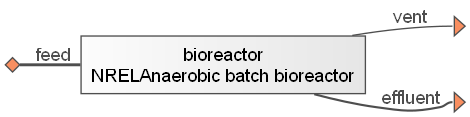

NRELAnaerobicBatchBioreactor: bioreactor
ins...
[0] feed  
    phase: 'l', T: 305.15 K, P: 101325 Pa
    flow (%): Water    80
              Glucose  20
              -------  1.5e+05 kg/hr
outs...
[0] vent  
    phase: 'g', T: 305.15 K, P: 101325 Pa
    flow (%): Water    1.87
              Ethanol  2.16
              CO2      96
              -------  1.05e+04 kg/hr
[1] effluent  
    phase: 'l', T: 305.15 K, P: 101325 Pa
    flow (%): Water    85.9
              Ethanol  10.3
              Glucose  0.0537
              CO2      2.79
              Yeast    1.02
              -------  1.4e+05 kg/hr


In [8]:
bioreactor = bst.NRELAnaerobicBatchBioreactor(
    ins=feed, 
    outs=('vent', 'effluent'),
    reactions=fermentation,
    T=T_operation,
    V_wf=f,
    V_max=V_max,
    tau=tau_reaction,
    tau_0=tau_cleanup,
    loading_time=tau_loading,
)
bioreactor.simulate()
bioreactor.diagram(format='png')
bioreactor.show('cwt')

In [9]:
bioreactor.results()

NRELAnaerobic batch bioreactor                          Units  bioreactor
Electricity              Power                             kW         117
                         Cost                          USD/hr        9.13
Chilled water            Duty                           kJ/hr   -1.45e+07
                         Flow                         kmol/hr    9.69e+03
                         Cost                          USD/hr        72.3
Design                   Reactor volume                    m3         933
                         Batch time                        hr          64
                         Loading time                      hr           1
                         Number of reactors                            11
                         Recirculation flow rate        m3/hr        13.1
                         Reactor duty                   kJ/hr   -1.45e+07
                         Cleaning and unloading time       hr           3
                         Working volume fraction                      0.9
Purchase cost            Heat exchangers (x11)            USD    2.21e+05
                         Reactors (x11)                   USD    5.01e+06
                         Agitators (x11)                  USD    3.12e+05
                         Cleaning in place                USD    1.98e+05
                         Recirculation pumps (x11)        USD    1.37e+05
Total purchase cost                                       USD    5.88e+06
Installed equipment cost                                  USD    9.14e+06
Utility cost                                           USD/hr        81.4

The NREL model has significantly lower capital. It is normal for equipment costs to vary this much, but they should be within the same order of magnitude. The main difference between the two methods is that the "standard" method is based on correlations of the average capital costs paid in industry while that the NREL model is based on preliminary vendor quotes obtained by the Harris Group. Additionally, the "standard" method may be over designed with a larger vessel and jacket thickness than necessary, which would lead to greater costs. While vendor quotes for capital costs may be more accurate, they are often optimistic and unforseen expenses may be incurred during construction.

## Mirobial oil aerobic bioreactor

The production of microbial oil is an aerobic process that can be modeled as the sum of 3 stoichiometric reactions: oil production from sugar, cell growth, and respiration (combustion of glucose). The substrate not converted to cell mass or oil is assumed to be consumed for respiration. Given the yield of triolein, Yp (wt %), and the specific yield of product per unit biomass, Yb (wt %,), the extent of each reaction can be calculated. 

$\text{Production}: \mathrm{Glucose \rightarrow 0.235\ H_2O + 2.53\ O_2  + 0.118\ Tripalmitin} $

$\text{Growth}: \mathrm{Glucose \rightarrow 1.7\ H_2O + 0.655\ CO_2 + 5.35\ Yeast[CH_{1.61}O_{0.56}]} $ <br>

$\text{Respiration}: \mathrm{Glucose + 6 O_2 \rightarrow 6 H_2O + 6 CO_2} $

We will assume the following fermentation performance:

* $\text{titer}$ - Product concentration: 27.4 g∙L<sup>-1</sup>
* $Y_p$ - Product yield: 18 wt %
* $Y_b$ - Specific yield of product per unit biomass: 63.56 wt %
* $F_\text{glucose,\ in}$ - Total glucose fed: 15,000 kg∙h<sup>-1</sup>

The specified yields can be translated to theoretical yields through the stoichiometric coefficients by weight (not by mol):

$ X_\text{production} = Y_p \cdot C_\text{wt, oil}^{-1} $ 

$ X_\text{growth} = Y_p \cdot Y_b^{-1} \cdot C_\text{wt, yeast}^{-1} $  

Product yields by weight can be directly set in [Reaction](../API/thermosteam/Reaction.txt) objects (so we can skip these calculations). 

In [10]:
titer = 27.4 # [g / L]
Yp = 0.18 # [by wt]
Yb = 0.6356 # [by wt]

bst.settings.set_thermo(
    ['Glucose', 
     'Water', 
     'CO2',
     'O2', 
     'N2', 
     bst.Chemical('MicrobialOil', search_ID='Tripalmitin', phase='l'), 
     'Yeast'],
    db='BioSTEAM',
)
chemicals = bst.settings.chemicals
production = bst.Reaction(
    "Glucose -> H2O + O2 + MicrobialOil", reactant='Glucose', X=1,
    correct_atomic_balance=True,
)
production.product_yield('MicrobialOil', basis='wt', product_yield=Yp)
growth = bst.Reaction(
    'Glucose -> H2O + CO2 + Yeast', 'Glucose', 1, 
    correct_atomic_balance=True
)
growth.product_yield('Yeast', basis='wt', product_yield=Yp/Yb)
respiration = bst.Reaction(
    'Glucose + O2 -> CO2 + H2O', 'Glucose', 1,
    correct_atomic_balance=True
)
fermentation = bst.ReactionSystem(
    bst.ParallelReaction([production, growth]), 
    respiration
)
fermentation.show()

ReactionSystem:
[0]  ParallelReaction (by mol):
     index  stoichiometry                                          reactant    X[%]
     [0]    Glucose -> 0.235 Water + 2.53 O2 + 0.118 MicrobialOil  Glucose    34.14
     [1]    Glucose -> 1.7 Water + 0.655 CO2 + 5.35 Yeast          Glucose    42.25
[1]  Reaction (by mol):
     stoichiometry                      reactant    X[%]
     Glucose + 6 O2 -> 6 Water + 6 CO2  Glucose   100.00


### Mass balance calculation

The same mass balance equations as the anaerobic case study still applies. However, instead of specifying the feed composition, now we specify the titer (i.e., concentration of product):

$ \text{titer} = F_\text{oil,\ out} \cdot \nu_{out}^{-1}$

Due to it's dependence on volume, the titer is a nonlinear function of the composition of the effluent.  Additionally, the flow rate of air required to meet the mass transfer requirement is also implicit (as we will discuss in the next section). It is therefore impossible to solve the mass balance explicitly. Instead, we must solve for the dilution water and air flow rate numerically. 

For now, we will ignore the mass transfer equation and simply assume that 100% of oxygen is consumed. Later, we will add the mass transfer relationship and solve the mass balance and mass transfer equations rigorously.

In [11]:
import flexsolve as flx

T = 32 + 273.15
feed = bst.Stream(
    Glucose=15e3, Water=85e3, units='kg/hr', 
    T=T_operation,
)
air = bst.Stream(
    O2=21, N2=79, units='kmol/hr',
    T=T_operation,
    phase='g',
)
vent = bst.Stream(phase='g')
broth = bst.Stream()
product = bst.MultiStream.from_streams([vent, broth])
product.T = T_operation

def objective(F_water): # Objective function
    feed.imol['Water'] = F_water
    
    # Convert the feed to product, ignoring O2 requirement
    broth.copy_like(feed)
    fermentation.force_reaction(broth)

    # Set air flow rate to satisfy O2 requirement (assume 100% is consumed)
    required_O2 = -broth.imol['O2'] + 1e-16
    air.imol['O2', 'N2'] = [required_O2, required_O2 * 79 / 21]

    # React with oxygen
    vent.empty()
    broth.mix_from([feed, air], energy_balance=False) # Isothermal
    fermentation(broth)

    # Perform vapor-liquid equilibrium
    aeration.vent_broth(vent, broth)
    # Alternatively, product.vle(T=T_operation, P=101325), but less accurate

    # Return error in titer
    actual_titer = broth.imass['MicrobialOil'] / broth.F_vol
    return actual_titer - titer

objective(feed.imol['Water'])
print()
feed.show('cwt')
print()
product.show('cwt')
print()
OUR = air.get_flow('mol/s', 'O2') # mol / s
print('Oxygen uptake rate:', f'{OUR:.3g}', '[mol/s]')


Stream: feed
phase: 'l', T: 305.15 K, P: 101325 Pa
flow (%): Glucose  15
          Water    85
          -------  1e+05 kg/hr

MultiStream: 
phases: ('g', 'l'), T: 305.15 K, P: 101325 Pa
flow (%): (g) Water         2.27
              CO2           54.7
              N2            43.1
              ------------  1.13e+04 kg/hr
          (l) Water         92.6
              CO2           0.0501
              N2            0.000927
              MicrobialOil  2.84
              Yeast         4.47
              ------------  9.51e+04 kg/hr

Oxygen uptake rate: 12.8 [mol/s]


## Bioreactor sizing

The same exact equations apply to size the bioreactor. We will need to make the following heurstic design specifications:

* $R$ - length to diameter: 3
* $V_{\mathrm{max}}$ - maximum reactor volume: 500 m3
* $f$ - working volume: 90%
* $\tau_{\mathrm{reaction}}$ - reaction time: 88 h
* $\tau_{\mathrm{cleaning}}$ - clean up time: 3 h
* $\tau_{\mathrm{loading}}$ - loading time: 1 h
* $R$ - height to diameter ratio: 3


In [12]:
from math import ceil, pi as π

# Heuristic specifications
R = 3
V_max = 500
f = 0.90
tau_reaction = 88
tau_cleanup = 3
tau_loading = 1

# Solve for number of reactors and the volume of an individual reactor 
𝜈 = product['l'].F_vol
V_total = 𝜈 * (tau_reaction + tau_cleanup + tau_loading) / f
N_reactors = ceil(V_total / V_max)
V_reactor = V_total / N_reactors
print('Number of reactors:', N_reactors)
print('Reactor volume:', f"{V_reactor:.3g}", 'm3')

# Solve for the diameter and height
D = (4 * V_reactor / π / R)**(1/3)
H = D * R
print('Reactor height:', f"{H:.3g}", 'm')
print('Reactor diameter:', f"{D:.3g}", 'm')

Number of reactors: 20
Reactor volume: 487 m3
Reactor height: 17.7 m
Reactor diameter: 5.91 m


### Mass transfer

Aerobic processes demand an oxygen uptake rate (OUR) which is satisfied by the oxygen transfer rate (OTR) under quasi steady-state. The main mass transfer resistance is at the boundary layer between the bubble and the liquid. The mass transfer resistance in the gas phase (within the small bubbles) and in the agitated liquid are both negligible. 

![Mass-transfer](./mass_transfer.png)

The basic mass tranfer equation at a height of x is therefore:

$ OTR = k_La(C_{sat} - C)_x $

For tall vessels (>1 m tall), the oxygen concentration are significantly different at the top and bottom of the reactor. We can account for the O<sub>2</sub> concentration gradient across the height by using the log-mean driving force:

$ OTR = k_La \frac{(C_{sat} - C)_{out} - (C_{sat} - C)_{in}}{ln\Big(\large \frac{(C_{sat} - C)_{out}}{(C_{sat} - C)_{in}} \Big)} $

The $k_La$ can be correlated to the superficail gas velocity, $U_S$, and the agitator power per unit volume, $P$, as follows:

$ k_La = AP^BU_S^C $

Where A, B, and C are correlation coefficients dependent on the agitator system, broth type, and size dimensions. The detailed design of the agitator is not relevant at this stage of the analysis, but the correlation coefficients will be a function of the agitator design.

The saturated oxygen concentration can be estimated using Henry's law:

$ C_{sat} = H \cdot P \cdot y$

$ H = k_H \cdot exp(A \cdot (1/T - 1/T_{ref}))$

Due to the liquid head, the pressure will vary across the tank as follows:

$P = P_{atm} + g \rho (1 - x / L) $

Where $g$ is the acceleration due to gravity, $\rho$ is the liquid density, and $x$ is the height of the fluid.

When estimating the OTR, it is important to keep track of units of measure and make sure all are consistent with the coefficients/correlations being used. To simplify the math, we will use BioSTEAM functions for estimating the the saturated oxygen concentration and the kLa. In the following code, we will estimate the air flow rate required to meet the oxygen uptake rate numerically.

**Assumptions**

* Assume a dissolved oxygen concentration of 50% saturation. Note that the flow rate of air (or agitation power) required to achieve an oxygen uptake rate equal to the oxygen transfer rate will depend on the oxygen saturation.
* Set the power consumed by the agitator to 0.2955 kW∙m3, a heuristic value common for industrial homogeneous reactions and comparable to estimates in Aspen plus. Note that is also possible to minimize power consumption by varying flow rate, but this would also lead to a greater capital cost for the compressor.
* Assume the Van't Riet’s non-viscous mass transfer correlation is applicable to estimate the overall mass transfer coefficient, kLa (lumped together with the specific interfacial area). 

In [13]:
from flexsolve import IQ_interpolation
g = bst.constants.g
theta_O2 = 0.5 # Dissolved oxygen concentration [% saturation]
kW_per_m3 = 0.2955 # Agitation power [kW / m3]
L = H * f # Length of filled vessel 
air.P = g * broth.rho * L + 101325 # Inlet air pressure
vent.P = 101325 # Outlet air pressure

def objective(air_flow):
    air.set_flow([air_flow * 0.21, air_flow * 0.79], 'mol/s', ['O2', 'N2'])

    # React with oxygen
    vent.empty()
    broth.mix_from([feed, air], energy_balance=False) # Isothermal mixing
    fermentation(broth)

    # Perform vapor-liquid equilibrium
    aeration.vent_broth(vent, broth)

    # Estimate kLa
    V_reactive = V_reactor * f
    fraction_operating = tau_reaction / (tau_reaction + tau_cleanup + tau_loading)
    agitation_power = 1e3 * kW_per_m3 * V_reactive # Power input in W
    F = air.get_total_flow('m3/s') / fraction_operating
    r = 0.5 * D
    A = π * r * r
    superficial_gas_flow = U = F / A # m / s 
    kLa = aeration.kLa_stirred_Riet(agitation_power, V_reactive, U) # 1 / s 
    
    # Estimate OTR [mol / s]
    P_O2_air = air.get_property('P', 'bar') * air.imol['O2'] / air.F_mol
    P_O2_vent = vent.get_property('P', 'bar') * vent.imol['O2'] / vent.F_mol
    C_O2_sat_air = aeration.C_O2_L(T_operation, P_O2_air) # mol / kg
    C_O2_sat_vent = aeration.C_O2_L(T_operation, P_O2_vent) # mol / kg
    LMDF = aeration.log_mean_driving_force(C_O2_sat_vent, C_O2_sat_air, theta_O2 * C_O2_sat_vent, theta_O2 * C_O2_sat_air)
    OTR = kLa * LMDF * broth.rho * V_total * fraction_operating # mol / s

    # Return error in estimate
    return OUR - OTR

minimum_air_flow_rate = OUR / 0.21
maximum_air_flow_rate = 10 * minimum_air_flow_rate
IQ_interpolation(objective, minimum_air_flow_rate, maximum_air_flow_rate) # Solve air flow

# Show stream results
feed.show('cwt')
print()
air.show('cwt')
print()
vent.show('cwt')
print()
broth.show('cwt')

Stream: feed
phase: 'l', T: 305.15 K, P: 101325 Pa
flow (%): Glucose  15
          Water    85
          -------  1e+05 kg/hr

Stream: air
phase: 'g', T: 305.15 K, P: 257495 Pa
flow (%): O2  23.3
          N2  76.7
          --  6.33e+03 kg/hr

Stream: vent
phase: 'g', T: 305.15 K, P: 101325 Pa
flow (%): Water  2.27
          CO2    54.6
          O2     0.00795
          N2     43.1
          -----  1.13e+04 kg/hr

Stream: broth
phase: 'l', T: 305.15 K, P: 101325 Pa
flow (%): Water         92.6
          CO2           0.0501
          O2            3.5e-07
          N2            0.000927
          MicrobialOil  2.84
          Yeast         4.47
          ------------  9.51e+04 kg/hr


### Energy balance calculation


### Aerobic bioreactor model

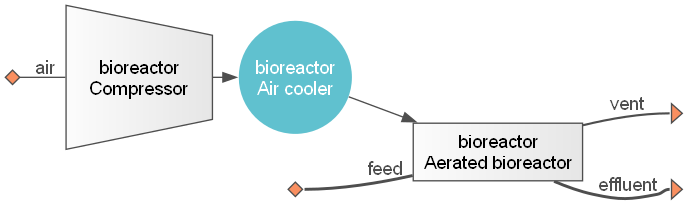

AeratedBioreactor: bioreactor
ins...
[0] feed  
    phase: 'l', T: 305.15 K, P: 101325 Pa
    flow (%): Glucose  15
              Water    85
              -------  1e+05 kg/hr
[1] air  
    phase: 'g', T: 305.15 K, P: 101325 Pa
    flow (%): O2  23.3
              N2  76.7
              --  2.05e+04 kg/hr
outs...
[0] vent  
    phase: 'g', T: 305.15 K, P: 101325 Pa
    flow (%): Water  2.72
              CO2    23.9
              O2     12.7
              N2     60.7
              -----  2.59e+04 kg/hr
[1] effluent  
    phase: 'l', T: 305.15 K, P: 101325 Pa
    flow (%): Water         92.6
              CO2           0.0204
              O2            0.000466
              N2            0.00108
              MicrobialOil  2.85
              Yeast         4.49
              ------------  9.46e+04 kg/hr


In [14]:
bioreactor = bst.AeratedBioreactor(
    ins=feed, 
    outs=('vent', 'effluent'),
    reactions=fermentation,
    T=T_operation,
    V_wf=f,
    V_max=V_max,
    tau=tau_reaction,
    tau_0=tau_cleanup,
    loading_time=tau_loading,
    length_to_diameter=R,
    method='Riet', # Name of method; Alternatively, 'Dewes' for bubble columns
    design='Stirred tank',  # Reactor type; Alternatively, 'Bubble column'
    heat_exchanger_configuration='jacketed',
    kW_per_m3=kW_per_m3,
    # Option to adjust both compressor and agitation power
    # to minimize the sum of both, yet still meet mass tranfer requirement 
    optimize_power=False, 
)
bioreactor.simulate()
bioreactor.diagram(format='png')
bioreactor.show('cwt')

In [15]:
bioreactor.sparged_gas.show('cwt')

Stream:  from <HXutility: air_cooler> to <AeratedBioreactor: bioreactor>
phase: 'g', T: 305.15 K, P: 265084 Pa
flow (%): O2  23.3
          N2  76.7
          --  2.05e+04 kg/hr


### Gas-fed Bioreactor Model
